In [1]:
import scanpy as sc
import os
import pandas as pd

In [2]:
import h5py
import pandas as pd
from scipy import sparse
from anndata import AnnData

file_path = '/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/data/1310_CNV.h5ad'

adata = sc.read_h5ad(file_path)

In [3]:
adata

AnnData object with n_obs × n_vars = 94919 × 5090
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'cell.id', 'cell_type_oct25', 'compartment', 'cnv_leiden_res0.1', 'cnv_leiden_res0.3', 'cnv_status', 'cnv_subclones'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'gene_id', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'cell_type_oct25_colors', 'cnv', 'cnv_leiden_res0.1', 'cnv_leiden_res0.1_colors', 'cnv_leiden_res0.3',

/tmp/ipykernel_2505778/3428110978.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,color='cnv_subclones',spot_size=20)
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1267: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


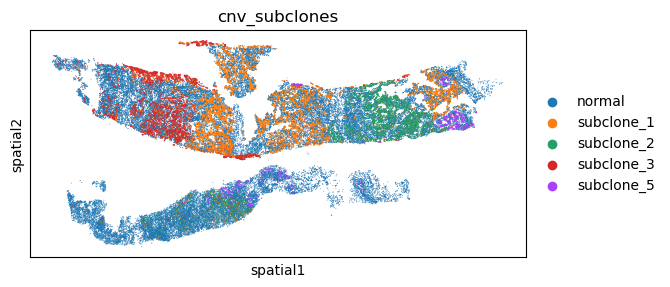

/tmp/ipykernel_2505778/3428110978.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,color='cell_type_oct25',spot_size=20)
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1267: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


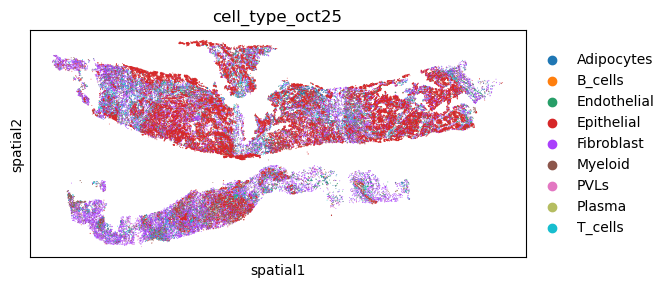

In [4]:
sc.pl.spatial(adata,color='cnv_subclones',spot_size=20)
sc.pl.spatial(adata,color='cell_type_oct25',spot_size=20)

## Pre- vs on-treatment clonal composition

This section summarizes the epithelial malignant compartment (`cell_type_oct25 == 'Epithelial'` and `cnv_subclones != 'normal'`) before the downstream niche analysis.

The plot below shows the relative epithelial subclone composition at each timepoint as stacked bars, with soft connectors between matching subclones to make the pre- to on-treatment shift easier to read.



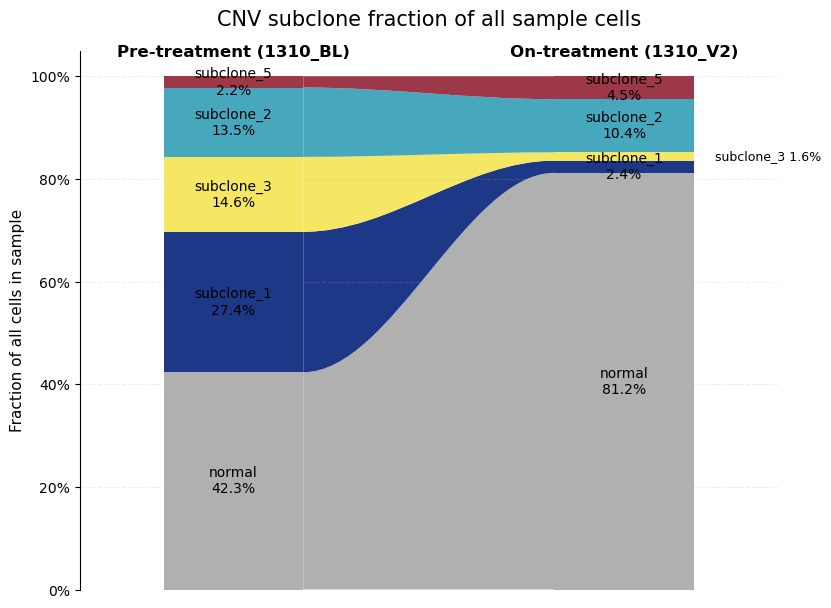

,Pre-treatment,On-treatment
cnv_subclones,,
normal,42.3%,81.2%
subclone_1,27.4%,2.4%
subclone_3,14.6%,1.6%
subclone_2,13.5%,10.4%
subclone_5,2.2%,4.5%


In [5]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt


def infer_treatment_label(sample_name):
    sample_name = str(sample_name)
    sample_upper = sample_name.upper()
    if any(token in sample_upper for token in ['BL', 'PRE', 'BASELINE']):
        return 'Pre-treatment'
    if any(token in sample_upper for token in ['ON', 'POST', 'TX', 'TRT', 'CYCLE', 'V', 'K']):
        return 'On-treatment'
    return sample_name

def compute_stacked_positions(values_by_clone, clone_order):
    positions = {}
    y_cursor = 0.0
    for clone in clone_order:
        height = float(values_by_clone.get(clone, 0.0))
        positions[clone] = (y_cursor, y_cursor + height)
        y_cursor += height
    return positions

def get_clone_color_map(adata, clone_order):
    clone_categories = [str(x) for x in adata.obs['cnv_subclones'].cat.categories]
    raw_colors = adata.uns['cnv_subclones_colors']

    parsed_colors = []
    for c in raw_colors:
        if isinstance(c, bytes):
            parsed_colors.append(c.decode('utf-8'))
        else:
            parsed_colors.append(str(c))

    full_color_map = dict(zip(clone_categories, parsed_colors))
    return {clone: full_color_map.get(clone, '#808080') for clone in clone_order}

def add_smooth_connector(ax, x0, x1, y0_bottom, y0_top, y1_bottom, y1_top, color, alpha=1):
    dx = x1 - x0
    c = dx * 0.35

    verts = [
        (x0, y0_top),
        (x0 + c, y0_top),
        (x1 - c, y1_top),
        (x1, y1_top),

        (x1, y1_bottom),

        (x1 - c, y1_bottom),
        (x0 + c, y0_bottom),
        (x0, y0_bottom),

        (x0, y0_top),
    ]

    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.LINETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.CLOSEPOLY,
    ]

    ax.add_patch(
        PathPatch(
            Path(verts, codes),
            facecolor=color,
            edgecolor='none',
            lw=0,
            alpha=alpha,
            zorder=1,
        )
    )

def plot_composition_transition(clone_comp_summary, left_title, right_title, color_map):
    clone_order = clone_comp_summary.index.tolist()
    left_values = clone_comp_summary.iloc[:, 0].to_dict()
    right_values = clone_comp_summary.iloc[:, 1].to_dict()

    left_positions = compute_stacked_positions(left_values, clone_order)
    right_positions = compute_stacked_positions(right_values, clone_order)

    fig, ax = plt.subplots(figsize=(9, 7))
    left_x0, left_x1 = 0.12, 0.32
    right_x0, right_x1 = 0.68, 0.88
    connector_x0, connector_x1 = left_x1, right_x0

    for clone in clone_order:
        left_y0, left_y1 = left_positions[clone]
        right_y0, right_y1 = right_positions[clone]
        color = color_map[clone]

        add_smooth_connector(
            ax,
            connector_x0,
            connector_x1,
            left_y0,
            left_y1,
            right_y0,
            right_y1,
            color=color,
            #alpha=0.65,
        )

        ax.add_patch(Rectangle(
            (left_x0, left_y0),
            left_x1 - left_x0,
            left_y1 - left_y0,
            facecolor=color,
            edgecolor='none',
            linewidth=0,
            #alpha=0.65,
            zorder=2,
        ))

        ax.add_patch(Rectangle(
            (right_x0, right_y0),
            right_x1 - right_x0,
            right_y1 - right_y0,
            facecolor=color,
            edgecolor='none',
            linewidth=0,
            #alpha=0.65,
            zorder=2,
        ))

        left_mid = (left_y0 + left_y1) / 2
        right_mid = (right_y0 + right_y1) / 2
        left_value = left_values[clone]
        right_value = right_values[clone]

        if left_value >= 0.02:
            ax.text((left_x0 + left_x1) / 2, left_mid, f"{clone}\n{left_value:.1%}",
                    ha='center', va='center', fontsize=10, color='black', zorder=3)
        else:
            ax.text(left_x0 - 0.03, left_mid, f"{clone} {left_value:.1%}",
                    ha='right', va='center', fontsize=9)

        if right_value >= 0.02:
            ax.text((right_x0 + right_x1) / 2, right_mid, f"{clone}\n{right_value:.1%}",
                    ha='center', va='center', fontsize=10, color='black', zorder=3)
        else:
            ax.text(right_x1 + 0.03, right_mid, f"{clone} {right_value:.1%}",
                    ha='left', va='center', fontsize=9)

    ax.text((left_x0 + left_x1) / 2, 1.03, left_title, ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text((right_x0 + right_x1) / 2, 1.03, right_title, ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.set_ylabel('Fraction of all cells in sample', fontsize=11)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.2)
    return fig, ax

clone_comp_df = (
    adata.obs[['sample', 'cnv_subclones']]
    .assign(
        sample=lambda df: df['sample'].astype(str),
        cnv_subclones=lambda df: df['cnv_subclones'].astype(str)
    )
    .groupby(['sample', 'cnv_subclones'])
    .size()
    .rename('n_cells')
    .reset_index()
)

total_cells_per_sample = (
    adata.obs.assign(sample=adata.obs['sample'].astype(str))
    .groupby('sample')
    .size()
)

clone_comp_df['fraction_within_sample'] = (
    clone_comp_df['n_cells'] /
    clone_comp_df['sample'].map(total_cells_per_sample)
)

samples = sorted(clone_comp_df['sample'].unique())
if len(samples) != 2:
    raise ValueError(f'Expected exactly two samples, found {len(samples)}: {samples}')

pre_sample, on_sample = samples
if infer_treatment_label(samples[0]) == 'On-treatment' and infer_treatment_label(samples[1]) == 'Pre-treatment':
    pre_sample, on_sample = samples[1], samples[0]

sample_label_map = {
    pre_sample: infer_treatment_label(pre_sample),
    on_sample: infer_treatment_label(on_sample),
}

pre_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == pre_sample]
    .set_index('cnv_subclones')['fraction_within_sample']
)
on_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == on_sample]
    .set_index('cnv_subclones')['fraction_within_sample']
)

clone_order = sorted(
    set(pre_series.index).union(on_series.index),
    key=lambda x: (-max(pre_series.get(x, 0), on_series.get(x, 0)), str(x))
)

clone_comp_summary = pd.DataFrame({
    sample_label_map[pre_sample]: pre_series.reindex(clone_order, fill_value=0.0),
    sample_label_map[on_sample]: on_series.reindex(clone_order, fill_value=0.0),
})

summary_display = clone_comp_df.copy()
summary_display['timepoint'] = summary_display['sample'].map(sample_label_map)
summary_display = summary_display.sort_values(
    ['timepoint', 'fraction_within_sample'],
    ascending=[True, False]
)
summary_display

cats = list(adata.obs['cnv_subclones'].cat.categories)
colors = list(adata.uns['cnv_subclones_colors'])
color_map = dict(zip(cats, colors))
color_map = {k: str(v) for k, v in color_map.items()}
color_map['normal'] = '#B0B0B0'


palette = ['#1e3888', '#47a8bd', '#f5e663', '#9c3848', '#ffad69']

# get clones (excluding 'normal')
clones = [c for c in clone_order if c != 'normal']

# assign palette
color_map = dict(zip(clones, palette))

color_map['normal'] = '#B0B0B0'
color_map['subclone_1'] = '#1e3888' #dark blue
color_map['subclone_2'] = '#47a8bd' #light blue
color_map['subclone_3'] = '#f5e663' #yellow
color_map['subclone_5'] = '#9c3848' #red

fig, ax = plot_composition_transition(
    clone_comp_summary,
    left_title=f"{sample_label_map[pre_sample]} ({pre_sample})",
    right_title=f"{sample_label_map[on_sample]} ({on_sample})",
    color_map=color_map,
)
ax.set_title('CNV subclone fraction of all sample cells', fontsize=15, pad=18)
plt.savefig('1310_CNV_subclone_change_BL_ontreat_all.svg')
plt.show()

clone_comp_summary.style.format('{:.1%}')

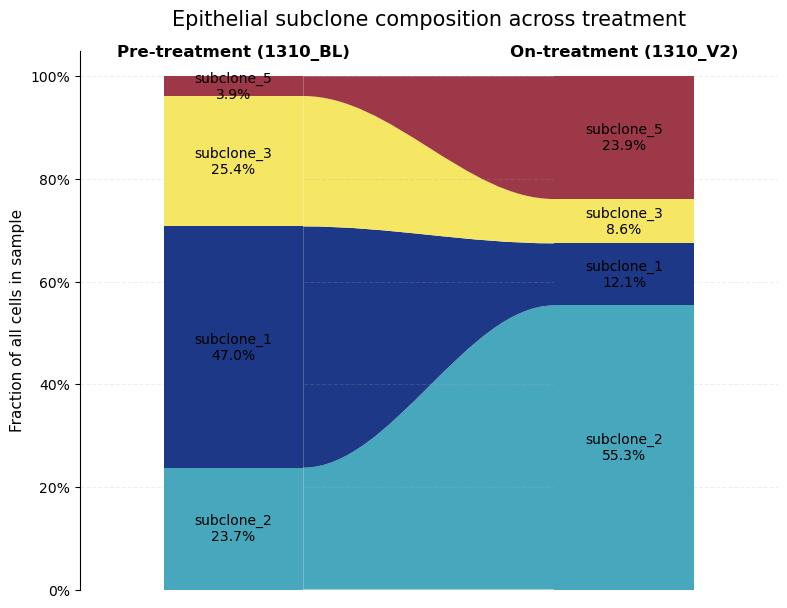

,Pre-treatment,On-treatment
cnv_subclones,,
subclone_2,24%,55%
subclone_1,47%,12%
subclone_3,25%,9%
subclone_5,4%,24%


In [6]:

malignant_mask = (
    (adata.obs['cell_type_oct25'] == 'Epithelial') &
    (adata.obs['cnv_subclones'].astype(str) != 'normal')
)

clone_comp_df = (
    adata.obs.loc[malignant_mask, ['sample', 'cnv_subclones']]
    .assign(
        cnv_subclones=lambda df: df['cnv_subclones'].astype(str),
        sample=lambda df: df['sample'].astype(str)
    )
    .groupby(['sample', 'cnv_subclones'])
    .size()
    .rename('n_cells')
    .reset_index()
)

clone_comp_df['fraction_within_malignant'] = (
    clone_comp_df.groupby('sample')['n_cells'].transform(lambda x: x / x.sum())
)

samples = sorted(clone_comp_df['sample'].unique())
if len(samples) != 2:
    raise ValueError(f'Expected exactly two samples, found {len(samples)}: {samples}')

pre_sample, on_sample = samples
if infer_treatment_label(samples[0]) == 'On-treatment' and infer_treatment_label(samples[1]) == 'Pre-treatment':
    pre_sample, on_sample = samples[1], samples[0]

sample_label_map = {
    pre_sample: infer_treatment_label(pre_sample),
    on_sample: infer_treatment_label(on_sample),
}

pre_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == pre_sample]
    .set_index('cnv_subclones')['fraction_within_malignant']
)
on_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == on_sample]
    .set_index('cnv_subclones')['fraction_within_malignant']
)

clone_order = sorted(
    set(pre_series.index).union(on_series.index),
    key=lambda x: (-max(pre_series.get(x, 0), on_series.get(x, 0)), str(x))
)

clone_comp_summary = pd.DataFrame({
    sample_label_map[pre_sample]: pre_series.reindex(clone_order, fill_value=0.0),
    sample_label_map[on_sample]: on_series.reindex(clone_order, fill_value=0.0),
})

summary_display = clone_comp_df.copy()
summary_display['timepoint'] = summary_display['sample'].map(sample_label_map)
summary_display = summary_display.sort_values(
    ['timepoint', 'fraction_within_malignant'],
    ascending=[True, False]
)
summary_display

# assign palette
color_map = dict()
color_map['normal'] = '#B0B0B0'
color_map['subclone_1'] = '#1e3888' #dark blue
color_map['subclone_2'] = '#47a8bd' #light blue
color_map['subclone_3'] = '#f5e663' #yellow
color_map['subclone_5'] = '#9c3848' #red



fig, ax = plot_composition_transition(
    clone_comp_summary,
    left_title=f"{sample_label_map[pre_sample]} ({pre_sample})",
    right_title=f"{sample_label_map[on_sample]} ({on_sample})",
    color_map=color_map,
)
ax.set_title('Epithelial subclone composition across treatment', fontsize=15, pad=18)
plt.savefig('1310_CNV_subclone_change_BL_ontreat_tumor.svg')
plt.show()

clone_comp_summary.style.format('{:.0%}')


In [7]:
color_map

{'normal': '#B0B0B0',
 'subclone_1': '#1e3888',
 'subclone_2': '#47a8bd',
 'subclone_3': '#f5e663',
 'subclone_5': '#9c3848'}

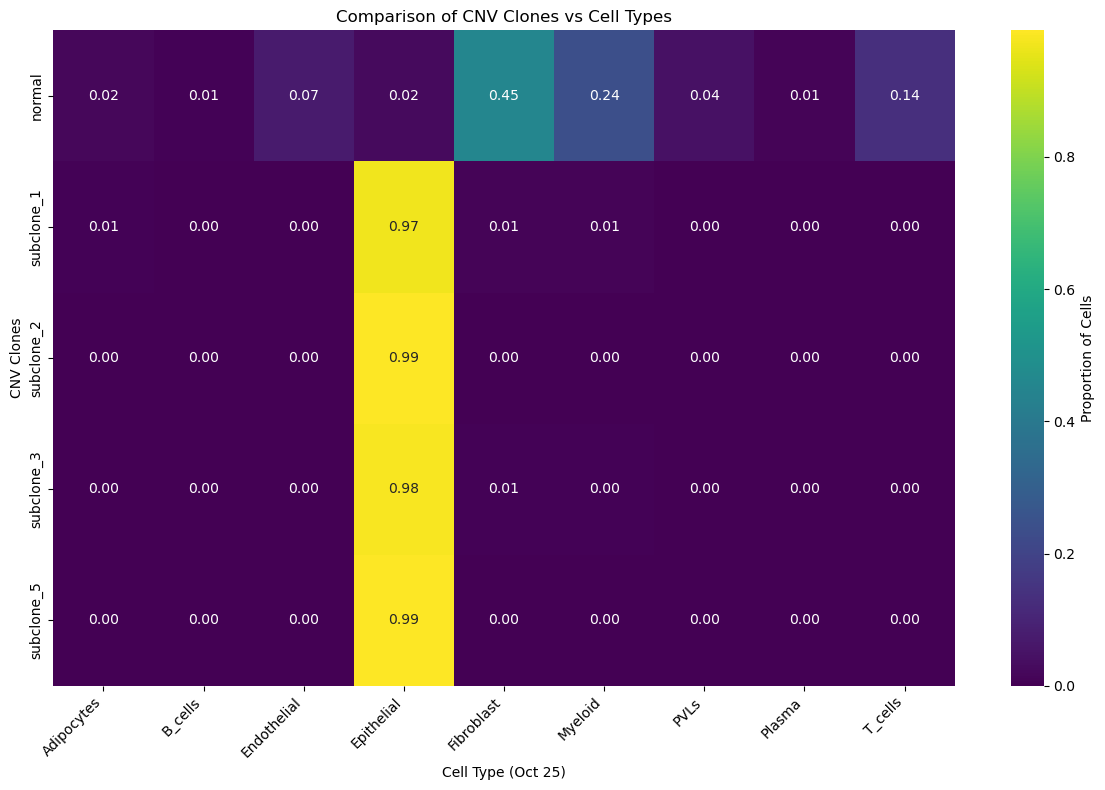

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the relevant observation data
df = adata.obs[['cnv_subclones', 'cell_type_oct25']]

# 2. Create the Crosstab (Counts)
# This shows the raw number of cells for each combination
ct_counts = pd.crosstab(df['cnv_subclones'], df['cell_type_oct25'])
ct_counts.to_csv('crosstab_counts.csv')

# 3. Create a Normalized Crosstab (Proportions)
# Normalizing by index (row) shows the percentage of each cell type within a clone
ct_norm = pd.crosstab(df['cnv_subclones'], df['cell_type_oct25'], normalize='index')

# 4. Visualization: Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(ct_norm, annot=True, cmap='viridis', fmt='.2f', cbar_kws={'label': 'Proportion of Cells'})
plt.title('Comparison of CNV Clones vs Cell Types')
plt.ylabel('CNV Clones')
plt.xlabel('Cell Type (Oct 25)')
plt.xticks(rotation=45, ha='right')
plt.savefig('cnv_celltype_comparison.svg')
plt.tight_layout()

In [9]:
adata.obs['sample'].unique()

['1310_BL', '1310_V2']
Categories (2, object): ['1310_BL', '1310_V2']

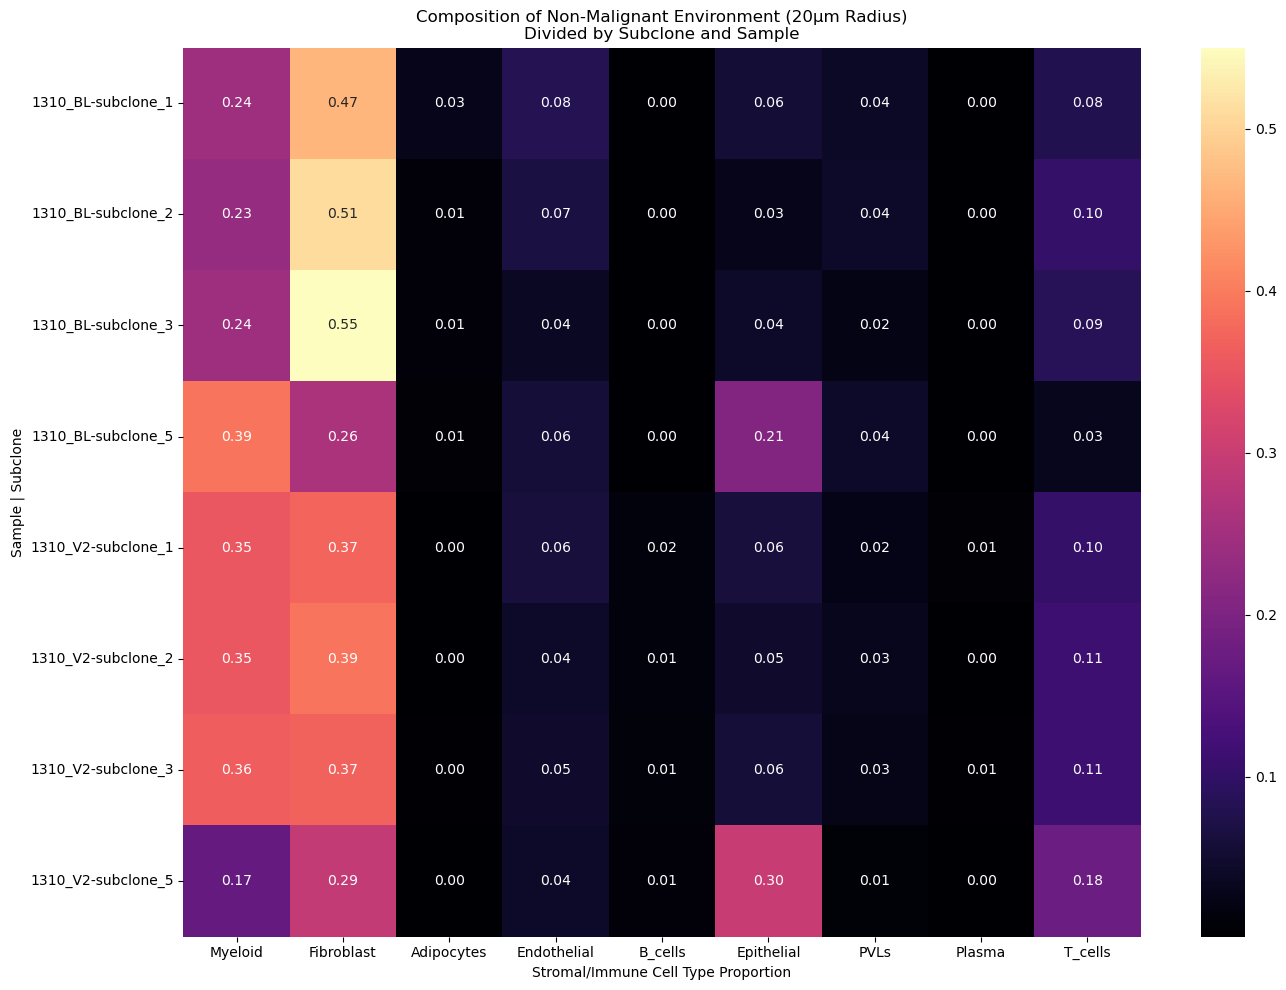

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# 1. Define the potential cancer cells
cancer_mask = (adata.obs['cell_type_oct25'] == 'Epithelial') & (adata.obs['cnv_subclones'] != 'normal')
adata.obs['is_cancer'] = cancer_mask

results = []
samples = adata.obs['sample'].unique()

for sample_id in samples:
    # Subset sample
    s_adata = adata[adata.obs['sample'] == sample_id].copy()
    coords = s_adata.obsm['spatial']
    
    # Identify indices of cancer cells
    # np.where returns a tuple, we take [0] to get the array of indices
    cancer_indices = np.where(s_adata.obs['is_cancer'])[0]
    
    # Check if there are cancer cells in this sample to avoid errors
    if len(cancer_indices) == 0:
        print(f"No cancer cells found in sample {sample_id}")
        continue

    # Indices of "Environment" cells (Non-cancer cells only)
    env_mask = ~s_adata.obs['is_cancer']
    env_indices = np.where(env_mask)[0]
    
    # Build Tree ONLY on the environment cells
    env_tree = KDTree(coords[env_indices])
    
    # Query: Find environment cells within 20um of each cancer cell
    neighbors_in_env = env_tree.query_ball_point(coords[cancer_indices], r=20)
    
    # 2. Calculate composition of the environment
    env_cell_types = s_adata.obs['cell_type_oct25'].values[env_indices]
    subclone_labels = s_adata.obs['cnv_subclones'].values[cancer_indices]
    
    composition_data = []
    for i, neighbor_hits in enumerate(neighbors_in_env):
        # We only care about cells that actually have neighbors within 20um
        if len(neighbor_hits) > 0:
            types = env_cell_types[neighbor_hits]
            counts = pd.Series(types).value_counts(normalize=True)
            counts['cnv_subclones'] = subclone_labels[i]
            counts['sample'] = sample_id
            composition_data.append(counts)
            
    if composition_data:
        sample_df = pd.DataFrame(composition_data).fillna(0)
        # Average the environment composition per subclone
        avg_composition = sample_df.groupby(['sample', 'cnv_subclones']).mean()
        results.append(avg_composition)

# 3. Final Visualization
if results:
    final_df = pd.concat(results)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(final_df, annot=True, cmap='magma', fmt='.2f')
    plt.title('Composition of Non-Malignant Environment (20μm Radius)\nDivided by Subclone and Sample')
    plt.ylabel('Sample | Subclone')
    plt.xlabel('Stromal/Immune Cell Type Proportion')
    plt.tight_layout()
    plt.show()
else:
    print("No spatial neighborhood data found to plot.")

/tmp/ipykernel_2505778/4246995887.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('sample')['cnv_subclones']


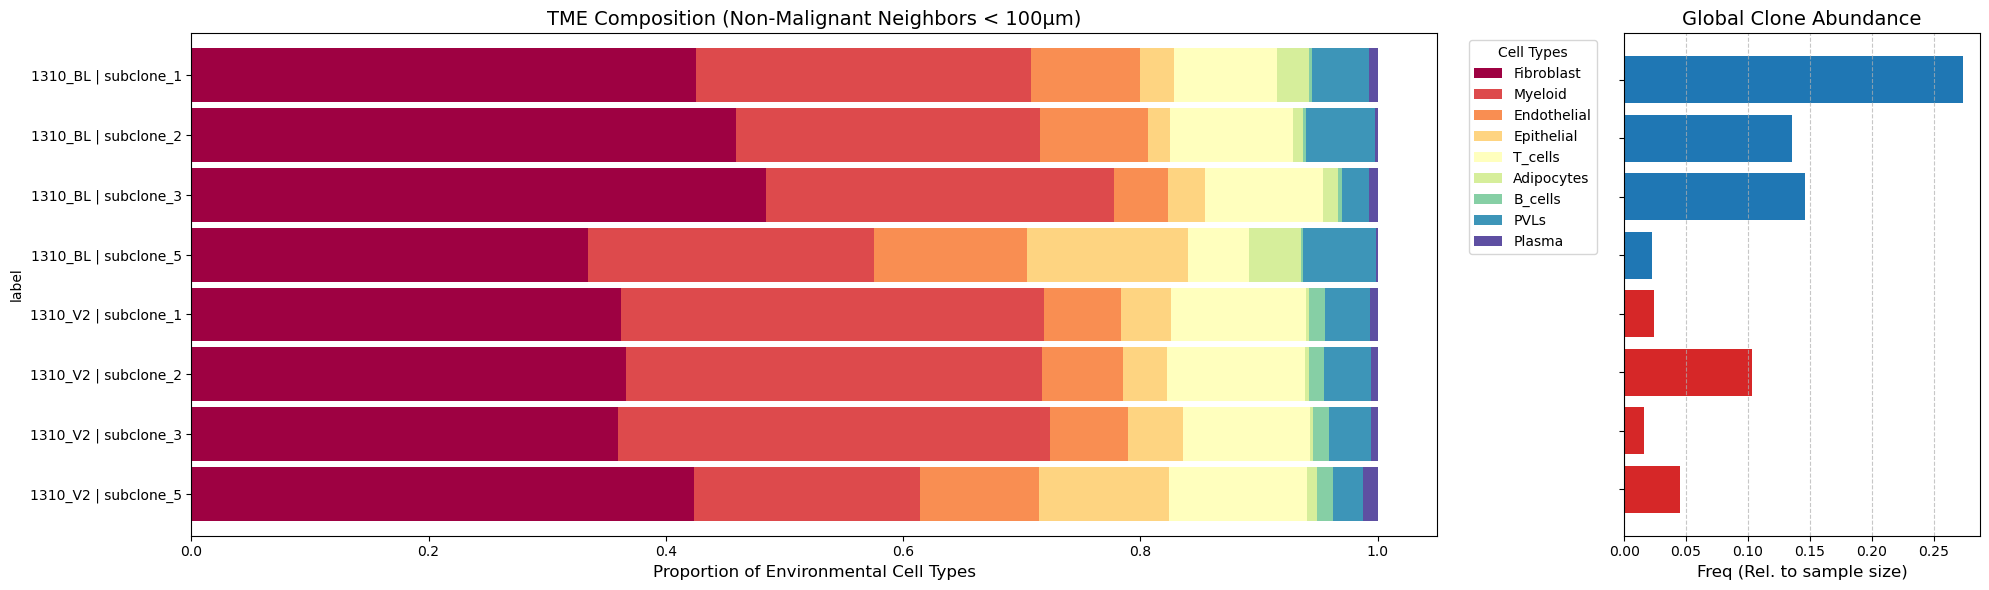

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# 1. Setup Data & Masks
cancer_mask = (adata.obs['cell_type_oct25'] == 'Epithelial') & (adata.obs['cnv_subclones'] != 'normal')
adata.obs['is_cancer'] = cancer_mask

# Calculate global frequencies relative to ALL cells in each sample
global_freqs = (
    adata.obs.groupby('sample')['cnv_subclones']
    .value_counts(normalize=True)
    .reset_index(name='global_freq')
)

results = []
samples = adata.obs['sample'].unique()
neighbor_radius = 100

for sample_id in samples:
    s_adata = adata[adata.obs['sample'] == sample_id].copy()
    coords = s_adata.obsm['spatial']

    cancer_indices = np.where(s_adata.obs['is_cancer'])[0]
    if len(cancer_indices) == 0:
        continue

    env_mask = ~s_adata.obs['is_cancer']
    env_indices = np.where(env_mask)[0]

    env_tree = KDTree(coords[env_indices])
    neighbors_in_env = env_tree.query_ball_point(coords[cancer_indices], r=neighbor_radius)

    env_cell_types = s_adata.obs['cell_type_oct25'].values[env_indices]
    subclone_labels = s_adata.obs['cnv_subclones'].values[cancer_indices]

    composition_data = []
    for i, neighbor_hits in enumerate(neighbors_in_env):
        if len(neighbor_hits) > 0:
            types = env_cell_types[neighbor_hits]
            counts = pd.Series(types).value_counts(normalize=True)
            counts['cnv_subclones'] = subclone_labels[i]
            composition_data.append(counts)

    if composition_data:
        sample_df = pd.DataFrame(composition_data).fillna(0)
        avg_comp = sample_df.groupby('cnv_subclones').mean()
        avg_comp['sample'] = sample_id
        results.append(avg_comp.reset_index())

# 2. Prepare Final Dataframe and SORT
viz_df = pd.concat(results).merge(global_freqs, on=['sample', 'cnv_subclones'])
viz_df['label'] = viz_df['sample'] + " | " + viz_df['cnv_subclones'].astype(str)
viz_df = viz_df.sort_values(['sample', 'cnv_subclones'], ascending=False).set_index('label')

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [3.5, 1]})

comp_cols = [c for c in viz_df.columns if c not in ['cnv_subclones', 'sample', 'global_freq']]
viz_df[comp_cols].plot(kind='barh', stacked=True, ax=ax1, colormap='Spectral', width=0.9)

ax1.set_title(f'TME Composition (Non-Malignant Neighbors < {neighbor_radius}μm)', fontsize=14)
ax1.set_xlabel('Proportion of Environmental Cell Types', fontsize=12)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Cell Types', fontsize=10)

sample_colors = ['#d62728' if 'V2' in label or 'K2' in label else '#1f77b4' for label in viz_df.index]
ax2.barh(viz_df.index, viz_df['global_freq'], color=sample_colors)
ax2.set_title('Global Clone Abundance', fontsize=14)
ax2.set_xlabel('Freq (Rel. to sample size)', fontsize=12)
ax2.set_yticklabels([])
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



Calculating shift from 1310_BL to 1310_V2...


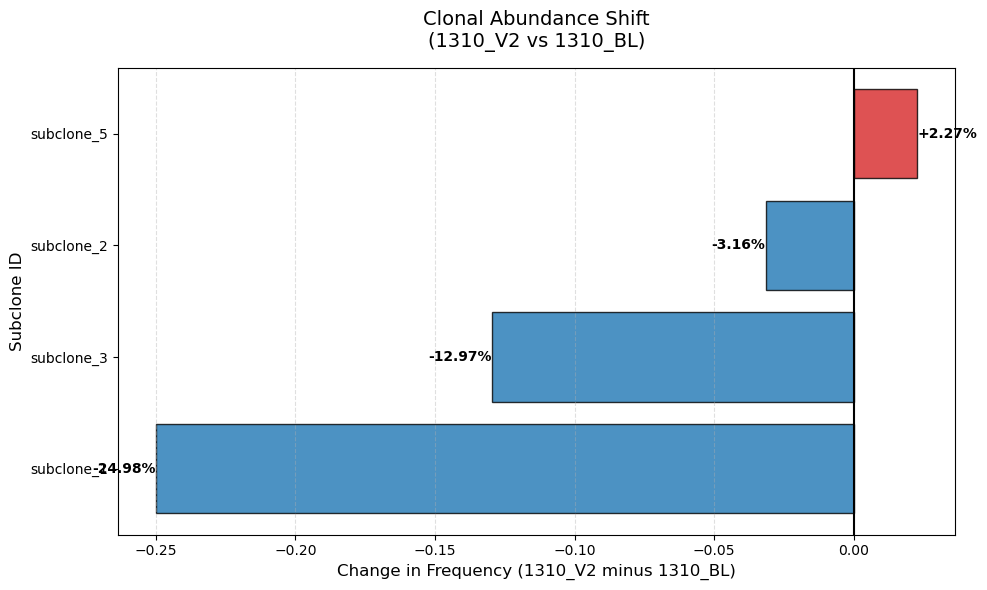

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify the unique samples dynamically
# Assuming two samples exist in the dataset
unique_samples = global_freqs['sample'].astype(str).unique()
unique_samples.sort()  # Sorts them (usually helps if naming is chronological like S1, S2)

if len(unique_samples) < 2:
    print(f"Only one sample found ({unique_samples[0]}). Need two to calculate a shift.")
else:
    s1, s2 = unique_samples[0], unique_samples[1]
    print(f"Calculating shift from {s1} to {s2}...")

    # 2. Pivot the frequencies
    shift_df = global_freqs.pivot(index='cnv_subclones', columns='sample', values='global_freq').fillna(0)

    # 3. Calculate Delta (Latest - Earliest)
    shift_df['diff'] = shift_df[s2] - shift_df[s1]

    # Sort by magnitude
    shift_df = shift_df.sort_values('diff', ascending=True)

    # Filter out 'normal' if present
    if 'normal' in shift_df.index:
        shift_df = shift_df.drop('normal')

    # 4. Plotting
    plt.figure(figsize=(10, 6))

    # Define colors based on the sign of the difference
    # Red for increase (Expansion), Blue for decrease (Reduction)
    colors = ['#d62728' if x > 0 else '#1f77b4' for x in shift_df['diff']]

    bars = plt.barh(shift_df.index.astype(str), shift_df['diff'], 
                    color=colors, edgecolor='black', alpha=0.8)

    # Reference line at zero
    plt.axvline(0, color='black', linewidth=1.5, linestyle='-')

    # Titles and Labels
    plt.title(f'Clonal Abundance Shift\n({s2} vs {s1})', fontsize=14, pad=15)
    plt.xlabel(f'Change in Frequency ({s2} minus {s1})', fontsize=12)
    plt.ylabel('Subclone ID', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    # Add text annotations for clarity
    for bar in bars:
        width = bar.get_width()
        plt.text(width + (width*0.001 if width > 0 else width*0.001), 
                 bar.get_y() + bar.get_height()/2, 
                 f'{width:+.2%}', 
                 va='center', 
                 ha='left' if width > 0 else 'right',
                 fontweight='bold',
                 fontsize=10)

    plt.tight_layout()
    plt.show()

Calculating TME shift from 1310_BL to 1310_V2...


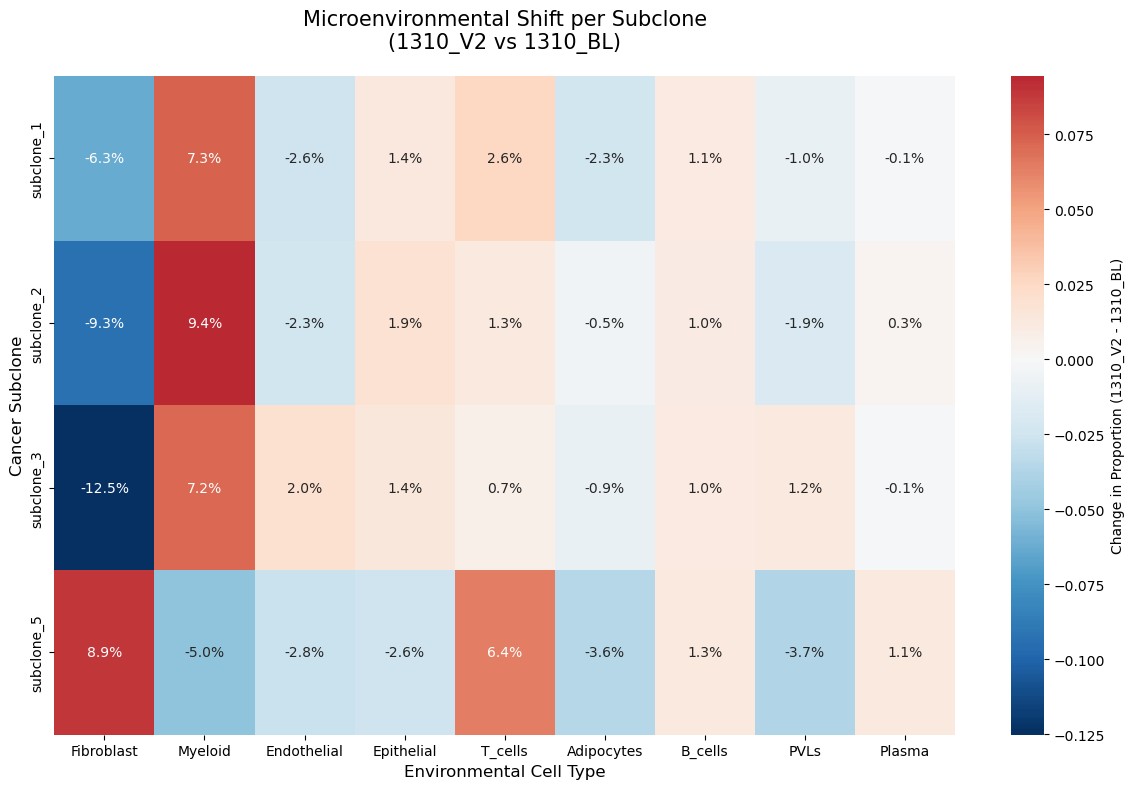

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify samples dynamically
unique_samples = viz_df['sample'].unique()
unique_samples.sort()

if len(unique_samples) < 2:
    print("Need at least two samples to calculate a shift.")
else:
    s1, s2 = unique_samples[0], unique_samples[1]
    print(f"Calculating TME shift from {s1} to {s2}...")

    # 2. Prepare the composition data
    # Drop non-composition columns
    exclude_cols = ['cnv_subclones', 'sample', 'global_freq']
    comp_cols = [c for c in viz_df.columns if c not in exclude_cols]
    
    # Create a pivot table: Index = Subclone, Columns = (Sample, CellType)
    pivot_df = viz_df.pivot(index='cnv_subclones', columns='sample', values=comp_cols)
    
    # 3. Calculate the Shift (s2 - s1)
    # This creates a dataframe where rows are clones and columns are the change in cell type %
    shift_matrix = pivot_df.xs(s2, axis=1, level=1) - pivot_df.xs(s1, axis=1, level=1)
    
    # Remove 'normal' if present and drop rows with all NaNs (clones present in only one sample)
    if 'normal' in shift_matrix.index:
        shift_matrix = shift_matrix.drop('normal')
    shift_matrix = shift_matrix.dropna(how='all')

    # 4. Plotting the TME Shift Heatmap
    plt.figure(figsize=(12, 8))
    
    # Use a diverging colormap: Red = Cell type increased near clone, Blue = Decreased
    sns.heatmap(shift_matrix, 
                annot=True, 
                fmt=".1%", 
                cmap="RdBu_r", 
                center=0, 
                cbar_kws={'label': f'Change in Proportion ({s2} - {s1})'})

    plt.title(f'Microenvironmental Shift per Subclone\n({s2} vs {s1})', fontsize=15, pad=20)
    plt.xlabel('Environmental Cell Type', fontsize=12)
    plt.ylabel('Cancer Subclone', fontsize=12)
    plt.tight_layout()
    plt.savefig("1310_microenvironmental_shift_per_subclone_heatmap.pdf")
    plt.show()

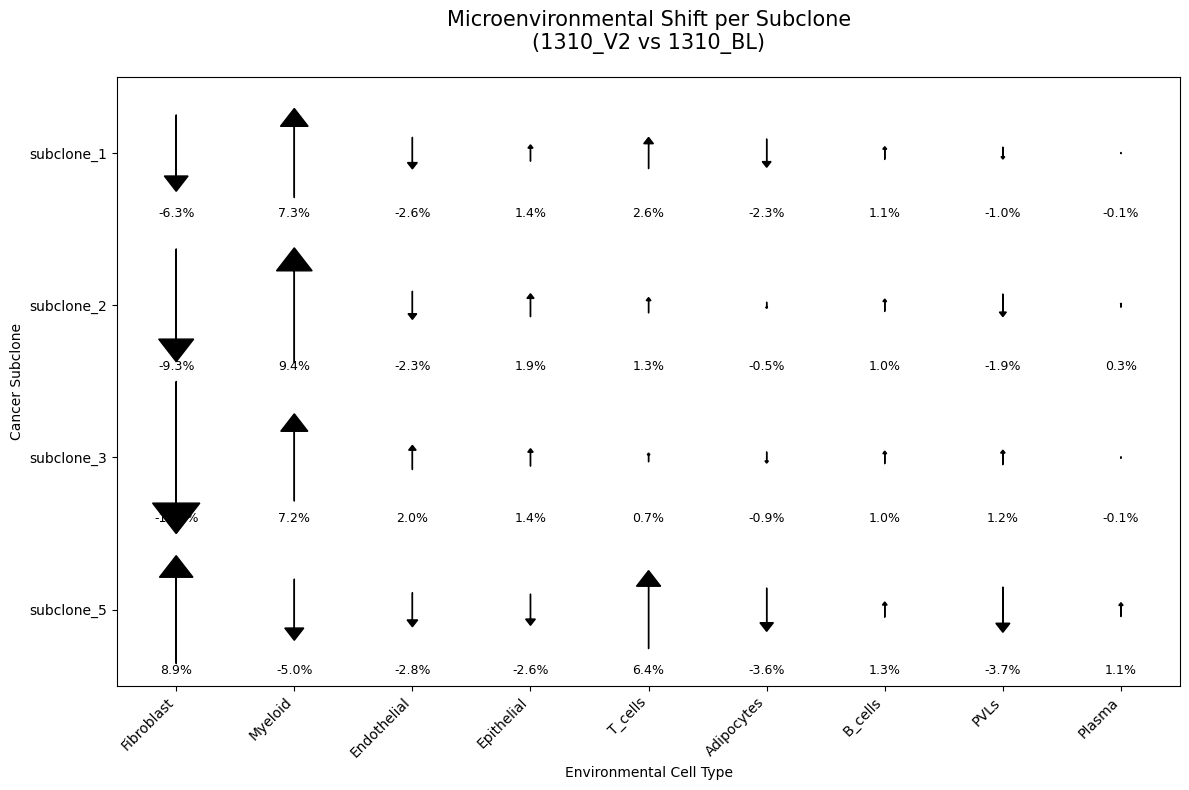

In [14]:
plt.figure(figsize=(12, 8))
ax = plt.gca()

# normalize magnitude for arrow scaling
max_val = np.abs(shift_matrix.values).max()

for i, clone in enumerate(shift_matrix.index):
    for j, celltype in enumerate(shift_matrix.columns):
        val = shift_matrix.loc[clone, celltype]

        if pd.isna(val):
            continue

        # direction
        direction = -1 if val > 0 else 1

        # scale arrow length (relative)
        length = (abs(val) / max_val) * 1  # scale factor

        # arrow properties
        dx = 0
        dy = direction * length

        ax.arrow(
            j + 0.5, i + 0.5 - dy/2,  # start position
            dx, dy,
            head_width=0.4*length,
            head_length=0.2*length,
            fc='black',
            ec='black',
            length_includes_head=True
        )

        # optional: add text label
        ax.text(
            j + 0.5, i + 0.9,
            f"{val:.1%}",
            ha='center', va='center',
            fontsize=9
        )

# formatting
ax.set_xticks(np.arange(len(shift_matrix.columns)) + 0.5)
ax.set_yticks(np.arange(len(shift_matrix.index)) + 0.5)

ax.set_xticklabels(shift_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(shift_matrix.index)

ax.set_xlim(0, len(shift_matrix.columns))
ax.set_ylim(0, len(shift_matrix.index))

ax.invert_yaxis()

ax.set_title(f'Microenvironmental Shift per Subclone\n({s2} vs {s1})', fontsize=15, pad=20)
ax.set_xlabel('Environmental Cell Type')
ax.set_ylabel('Cancer Subclone')

# remove grid clutter
ax.grid(False)

plt.tight_layout()
plt.show()

In [15]:
adata

AnnData object with n_obs × n_vars = 94919 × 5090
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'cell.id', 'cell_type_oct25', 'compartment', 'cnv_leiden_res0.1', 'cnv_leiden_res0.3', 'cnv_status', 'cnv_subclones', 'is_cancer'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'gene_id', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'cell_type_oct25_colors', 'cnv', 'cnv_leiden_res0.1', 'cnv_leiden_res0.1_colors', 'cnv_le

Calculating TME shift from 1310_BL to 1310_V2...


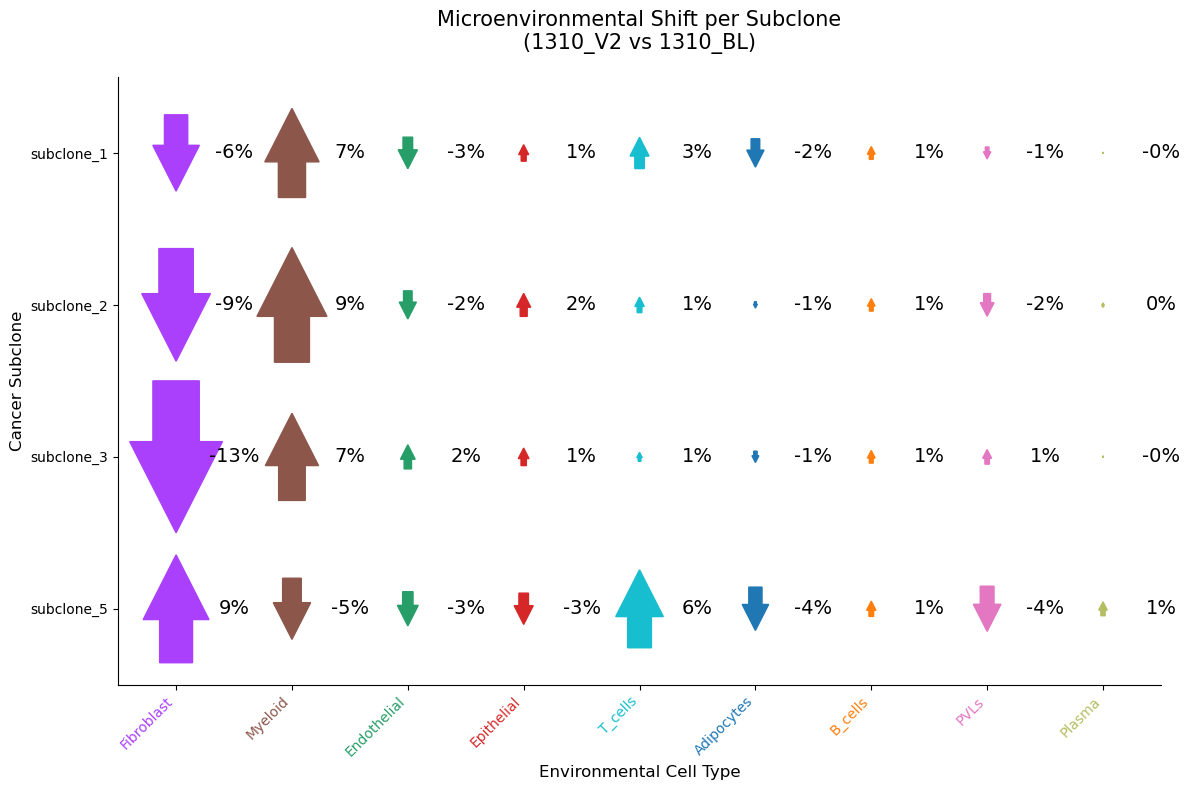

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Identify samples
# -----------------------------
unique_samples = viz_df['sample'].unique()
unique_samples.sort()

if len(unique_samples) < 2:
    raise ValueError("Need at least two samples to calculate a shift.")

s1, s2 = unique_samples[0], unique_samples[1]
print(f"Calculating TME shift from {s1} to {s2}...")

# -----------------------------
# 2. Prepare composition matrix
# -----------------------------
exclude_cols = ['cnv_subclones', 'sample', 'global_freq']
comp_cols = [c for c in viz_df.columns if c not in exclude_cols]

pivot_df = viz_df.pivot(
    index='cnv_subclones',
    columns='sample',
    values=comp_cols
)

shift_matrix = (
    pivot_df.xs(s2, axis=1, level=1)
    - pivot_df.xs(s1, axis=1, level=1)
)

# Remove normal clone if present
if 'normal' in shift_matrix.index:
    shift_matrix = shift_matrix.drop('normal')

shift_matrix = shift_matrix.dropna(how='all')

# -----------------------------
# 3. Cell-type color map
# -----------------------------
celltypes = list(adata.obs['cell_type_oct25'].cat.categories)
colors = adata.uns['cell_type_oct25_colors']

celltype_color_map = dict(zip(celltypes, colors))

# -----------------------------
# 4. Arrow plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 8))

max_val = np.abs(shift_matrix.values).max()

for i, clone in enumerate(shift_matrix.index):
    for j, celltype in enumerate(shift_matrix.columns):
        val = shift_matrix.loc[clone, celltype]

        if pd.isna(val):
            continue

        # direction: up for increase, down for decrease
        direction = -1 if val > 0 else 1

        # scale arrow by magnitude
        length = (abs(val) / max_val) * 1.0

        dx = 0
        dy = direction * length

        color = celltype_color_map.get(celltype, 'black')

        ax.arrow(
            j + 0.5,
            i + 0.5 - dy / 2,
            dx,
            dy,
            width=0.4 * length,   # ← controls thickness
            head_width=0.8 * length,
            head_length=0.6 * length,
            fc=color,
            ec=color,
            length_includes_head=True
        )


        ax.text(
            j + 1,
            i + 0.5,
            f"{val:.0%}",
            ha='center',
            va='center',
            fontsize=14
        )

# -----------------------------
# 5. Formatting
# -----------------------------
ax.set_xticks(np.arange(len(shift_matrix.columns)) + 0.5)
ax.set_yticks(np.arange(len(shift_matrix.index)) + 0.5)

ax.set_xticklabels(shift_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(shift_matrix.index)

# color x-axis labels by cell type
for label in ax.get_xticklabels():
    celltype = label.get_text()
    label.set_color(celltype_color_map.get(celltype, 'black'))

ax.set_xlim(0, len(shift_matrix.columns))
ax.set_ylim(0, len(shift_matrix.index))
ax.invert_yaxis()

ax.set_title(
    f'Microenvironmental Shift per Subclone\n({s2} vs {s1})',
    fontsize=15,
    pad=20
)
ax.set_xlabel('Environmental Cell Type', fontsize=12)
ax.set_ylabel('Cancer Subclone', fontsize=12)

ax.grid(False)

# optional: remove spines
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("1310_microenvironmental_shift_per_subclone_coloredarrows.pdf")
plt.show()

In [17]:
adata.uns['cnv_subclones_colors']

array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc'],
      dtype=object)

Using baseline sample: 1310_BL


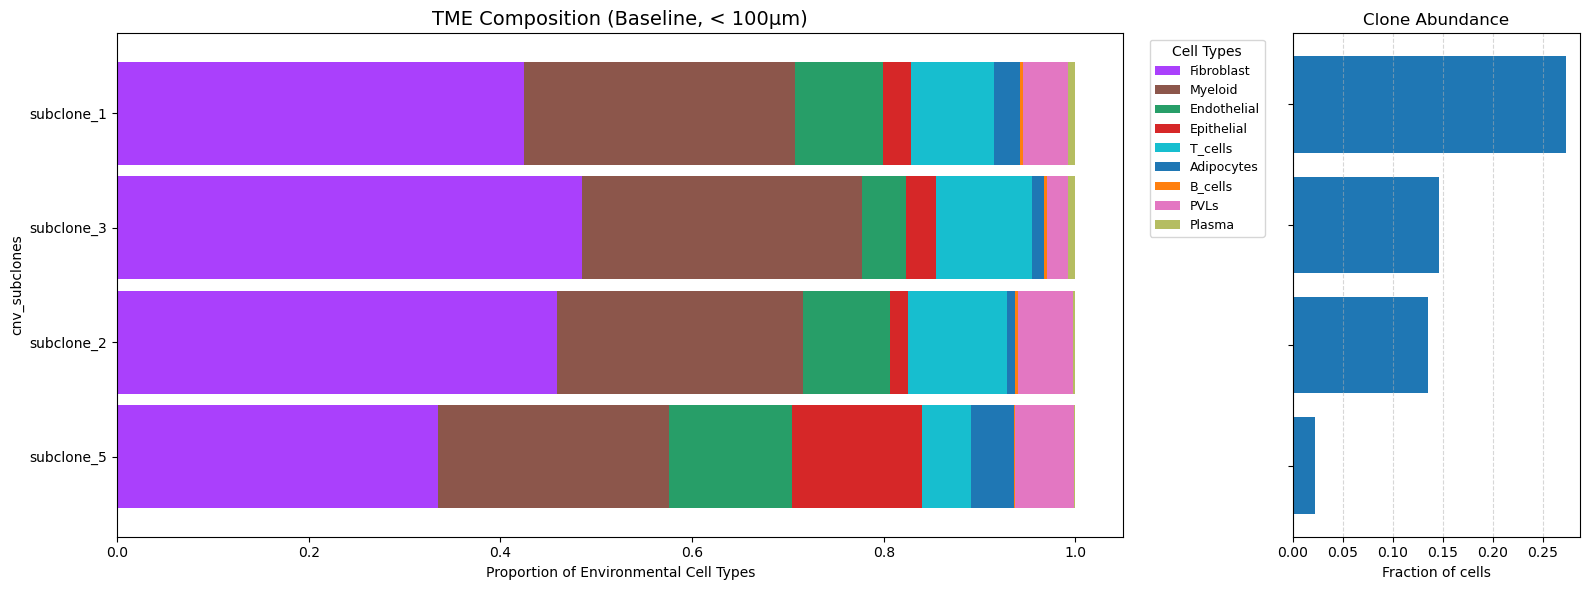

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# -----------------------------
# 0. Select baseline sample
# -----------------------------
baseline_sample = [s for s in adata.obs['sample'].unique() if 'BL' in str(s) or 'baseline' in str(s).lower()][0]
print(f"Using baseline sample: {baseline_sample}")

adata_sub = adata[adata.obs['sample'] == baseline_sample].copy()

# -----------------------------
# 1. Setup masks
# -----------------------------
cancer_mask = (adata_sub.obs['cell_type_oct25'] == 'Epithelial') & (adata_sub.obs['cnv_subclones'] != 'normal')
adata_sub.obs['is_cancer'] = cancer_mask

# global frequencies (baseline only)
global_freqs = (
    adata_sub.obs['cnv_subclones']
    .value_counts(normalize=True)
    .rename('global_freq')
    .reset_index()
    .rename(columns={'index': 'cnv_subclones'})
)

# -----------------------------
# 2. Spatial neighborhood analysis
# -----------------------------
coords = adata_sub.obsm['spatial']

cancer_indices = np.where(adata_sub.obs['is_cancer'])[0]
env_mask = ~adata_sub.obs['is_cancer']
env_indices = np.where(env_mask)[0]

neighbor_radius = 100

env_tree = KDTree(coords[env_indices])
neighbors_in_env = env_tree.query_ball_point(coords[cancer_indices], r=neighbor_radius)

env_cell_types = adata_sub.obs['cell_type_oct25'].values[env_indices]
subclone_labels = adata_sub.obs['cnv_subclones'].values[cancer_indices]

composition_data = []

for i, neighbor_hits in enumerate(neighbors_in_env):
    if len(neighbor_hits) > 0:
        types = env_cell_types[neighbor_hits]
        counts = pd.Series(types).value_counts(normalize=True)
        counts['cnv_subclones'] = subclone_labels[i]
        composition_data.append(counts)

# -----------------------------
# 3. Aggregate
# -----------------------------
sample_df = pd.DataFrame(composition_data).fillna(0)
avg_comp = sample_df.groupby('cnv_subclones').mean()

viz_df = avg_comp.merge(global_freqs, on='cnv_subclones')
viz_df = viz_df.sort_values('global_freq', ascending=True)
viz_df = viz_df.set_index('cnv_subclones')

# -----------------------------
# 4. Cell type colors
# -----------------------------
celltypes = list(adata.obs['cell_type_oct25'].cat.categories)
colors = list(adata.uns['cell_type_oct25_colors'])

celltype_color_map = dict(zip(celltypes, colors))

comp_cols = [c for c in viz_df.columns if c != 'global_freq']

# ensure order + colors match
comp_cols = [c for c in comp_cols if c in celltype_color_map]

bar_colors = [celltype_color_map[c] for c in comp_cols]

# -----------------------------
# 5. Plot
# -----------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 6),
    gridspec_kw={'width_ratios': [3.5, 1]}
)

# stacked TME composition
viz_df[comp_cols].plot(
    kind='barh',
    stacked=True,
    ax=ax1,
    color=bar_colors,
    width=0.9
)

ax1.set_title(f'TME Composition (Baseline, < {neighbor_radius}μm)', fontsize=14)
ax1.set_xlabel('Proportion of Environmental Cell Types')
ax1.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title='Cell Types',
    fontsize=9
)

# global clone abundance
ax2.barh(
    viz_df.index,
    viz_df['global_freq'],
    color='#1f77b4'
)

ax2.set_title('Clone Abundance')
ax2.set_xlabel('Fraction of cells')
ax2.set_yticklabels([])
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("1310_TME_comp_per_subclone_barplot.pdf")

plt.show()

In [19]:
adata

AnnData object with n_obs × n_vars = 94919 × 5090
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'cell.id', 'cell_type_oct25', 'compartment', 'cnv_leiden_res0.1', 'cnv_leiden_res0.3', 'cnv_status', 'cnv_subclones', 'is_cancer'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'gene_id', 'symbol', 'ensg', 'chromosome', 'start', 'end'
    uns: 'cell_type_oct25_colors', 'cnv', 'cnv_leiden_res0.1', 'cnv_leiden_res0.1_colors', 'cnv_le

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Identify samples
# -----------------------------
unique_samples = viz_df['sample'].unique()
unique_samples.sort()

if len(unique_samples) < 2:
    raise ValueError("Need at least two samples to calculate a shift.")

s1, s2 = unique_samples[0], unique_samples[1]
print(f"Calculating TME shift from {s1} to {s2}...")

# -----------------------------
# 2. Prepare composition matrix
# -----------------------------
exclude_cols = ['cnv_subclones', 'sample', 'global_freq']
comp_cols = [c for c in viz_df.columns if c not in exclude_cols]

pivot_df = viz_df.pivot(
    index='cnv_subclones',
    columns='sample',
    values=comp_cols
)

shift_matrix = (
    pivot_df.xs(s2, axis=1, level=1)
    - pivot_df.xs(s1, axis=1, level=1)
)

# Remove normal clone if present
if 'normal' in shift_matrix.index:
    shift_matrix = shift_matrix.drop('normal')

shift_matrix = shift_matrix.dropna(how='all')

# -----------------------------
# 3. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 8))

max_val = np.abs(shift_matrix.values).max()

for i, clone in enumerate(shift_matrix.index):
    for j, celltype in enumerate(shift_matrix.columns):
        val = shift_matrix.loc[clone, celltype]

        if pd.isna(val):
            continue

        # direction (same as your version)
        direction = -1 if val > 0 else 1

        # color by sign
        color = 'green' if val > 0 else 'red'

        # scale arrow length
        length = (abs(val) / max_val) * 1.0

        dx = 0
        dy = direction * length

        ax.arrow(
            j + 0.5,
            i + 0.5 - dy / 2,
            dx,
            dy,
            width=0.4 * length,   # ← controls thickness
            head_width=0.8 * length,
            head_length=0.6 * length,
            fc=color,
            ec=color,
            length_includes_head=True
        )


        ax.text(
            j + 1,
            i + 0.5,
            f"{val:.0%}",
            ha='center',
            va='center',
            fontsize=12
        )
# -----------------------------
# 4. Formatting
# -----------------------------
ax.set_xticks(np.arange(len(shift_matrix.columns)) + 0.5)
ax.set_yticks(np.arange(len(shift_matrix.index)) + 0.5)

ax.set_xticklabels(shift_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(shift_matrix.index)

ax.set_xlim(0, len(shift_matrix.columns))
ax.set_ylim(0, len(shift_matrix.index))
ax.invert_yaxis()

ax.set_title(
    f'Microenvironmental Shift per Subclone\n({s2} vs {s1})',
    fontsize=15,
    pad=20
)
ax.set_xlabel('Environmental Cell Type', fontsize=12)
ax.set_ylabel('Cancer Subclone', fontsize=12)

ax.grid(False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

KeyError: 'sample'

In [ ]:
#### Calculate total remodeling magnitude
remodeling_magnitude = shift_matrix.abs().sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
remodeling_magnitude.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Total TME Remodeling Magnitude per Clone')
plt.ylabel('Sum of Absolute Proportion Changes')
plt.xlabel('Subclone ID')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
viz_df

## Clone-specific TME comparisons across timepoints

These panels compare the non-malignant neighborhood around each malignant subclone between baseline and on-treatment samples. The first block shows side-by-side heatmaps for each timepoint plus a delta panel, and the second block tests whether the same differences are strongest close to the clone core or in broader rings around the clone.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import KDTree


def infer_sample_order(sample_names):
    sample_names = [str(s) for s in sample_names]
    sample_names = sorted(sample_names)

    def label(sample_name):
        sample_upper = sample_name.upper()
        if any(token in sample_upper for token in ['BL', 'PRE', 'BASELINE']):
            return 'Pre-treatment'
        if any(token in sample_upper for token in ['ON', 'POST', 'TX', 'TRT', 'CYCLE', 'V', 'K']):
            return 'On-treatment'
        return sample_name

    if len(sample_names) != 2:
        return sample_names, {s: label(s) for s in sample_names}

    first, second = sample_names
    if label(first) == 'On-treatment' and label(second) == 'Pre-treatment':
        sample_names = [second, first]

    return sample_names, {s: label(s) for s in sample_names}


def summarize_clone_tme(adata, radius=100):
    records = []
    sample_ids = sorted(adata.obs['sample'].astype(str).unique())

    for sample_id in sample_ids:
        s_adata = adata[adata.obs['sample'].astype(str) == sample_id].copy()
        coords = s_adata.obsm['spatial']

        cancer_mask = (s_adata.obs['cell_type_oct25'] == 'Epithelial') & (s_adata.obs['cnv_subclones'].astype(str) != 'normal')
        env_mask = ~cancer_mask

        cancer_idx = np.where(cancer_mask)[0]
        env_idx = np.where(env_mask)[0]
        if len(cancer_idx) == 0 or len(env_idx) == 0:
            continue

        env_tree = KDTree(coords[env_idx])
        neighbor_lists = env_tree.query_ball_point(coords[cancer_idx], r=radius)
        env_types = s_adata.obs['cell_type_oct25'].astype(str).values[env_idx]
        clone_labels = s_adata.obs['cnv_subclones'].astype(str).values[cancer_idx]

        for clone, hits in zip(clone_labels, neighbor_lists):
            if len(hits) == 0:
                continue
            counts = pd.Series(env_types[hits]).value_counts(normalize=True)
            for cell_type, proportion in counts.items():
                records.append({
                    'sample': sample_id,
                    'subclone': clone,
                    'neighbor_type': cell_type,
                    'proportion': proportion,
                    'radius': radius,
                })

    return pd.DataFrame(records)


def summarize_clone_tme_rings(adata, ring_edges=(0, 20, 50, 100)):
    records = []
    sample_ids = sorted(adata.obs['sample'].astype(str).unique())

    for sample_id in sample_ids:
        s_adata = adata[adata.obs['sample'].astype(str) == sample_id].copy()
        coords = s_adata.obsm['spatial']

        cancer_mask = (s_adata.obs['cell_type_oct25'] == 'Epithelial') & (s_adata.obs['cnv_subclones'].astype(str) != 'normal')
        env_mask = ~cancer_mask

        cancer_idx = np.where(cancer_mask)[0]
        env_idx = np.where(env_mask)[0]
        if len(cancer_idx) == 0 or len(env_idx) == 0:
            continue

        env_coords = coords[env_idx]
        env_types = s_adata.obs['cell_type_oct25'].astype(str).values[env_idx]
        clone_labels = s_adata.obs['cnv_subclones'].astype(str).values[cancer_idx]
        env_tree = KDTree(env_coords)
        max_radius = ring_edges[-1]

        for cell_idx, clone in zip(cancer_idx, clone_labels):
            hits = env_tree.query_ball_point(coords[cell_idx], r=max_radius)
            if len(hits) == 0:
                continue

            hit_indices = np.array(hits, dtype=int)
            dists = np.linalg.norm(env_coords[hit_indices] - coords[cell_idx], axis=1)
            hit_types = env_types[hit_indices]

            for inner, outer in zip(ring_edges[:-1], ring_edges[1:]):
                ring_mask = (dists > inner) & (dists <= outer)
                if not ring_mask.any():
                    continue
                ring_counts = pd.Series(hit_types[ring_mask]).value_counts(normalize=True)
                ring_label = f'{inner}-{outer} μm'
                for cell_type, proportion in ring_counts.items():
                    records.append({
                        'sample': sample_id,
                        'subclone': clone,
                        'neighbor_type': cell_type,
                        'ring': ring_label,
                        'proportion': proportion,
                    })

    return pd.DataFrame(records)


sample_order, sample_label_map = infer_sample_order(adata.obs['sample'].astype(str).unique())
if len(sample_order) != 2:
    raise ValueError(f'Expected exactly two samples for clone TME comparison, found {sample_order}')

clone_tme_df = summarize_clone_tme(adata, radius=100)
clone_tme_summary = (
    clone_tme_df.groupby(['sample', 'subclone', 'neighbor_type'])['proportion']
    .mean()
    .reset_index()
)

all_neighbor_types = sorted(clone_tme_summary['neighbor_type'].unique())
all_subclones = sorted(
    clone_tme_summary['subclone'].unique(),
    key=lambda clone: (
        -clone_tme_summary.loc[clone_tme_summary['subclone'] == clone, 'proportion'].mean(),
        str(clone),
    )
)

heatmaps_by_sample = {}
for sample_id in sample_order:
    heatmaps_by_sample[sample_id] = (
        clone_tme_summary[clone_tme_summary['sample'] == sample_id]
        .pivot(index='subclone', columns='neighbor_type', values='proportion')
        .reindex(index=all_subclones, columns=all_neighbor_types)
        .fillna(0)
    )

delta_tme = heatmaps_by_sample[sample_order[1]] - heatmaps_by_sample[sample_order[0]]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 1, 1.1]})
vmax = max(h.values.max() for h in heatmaps_by_sample.values())

for ax, sample_id in zip(axes[:2], sample_order):
    sns.heatmap(
        heatmaps_by_sample[sample_id],
        ax=ax,
        cmap='magma',
        vmin=0,
        vmax=vmax,
        annot=True,
        fmt='.2f',
        cbar=ax is axes[1],
        cbar_kws={'label': 'Mean neighborhood proportion'} if ax is axes[1] else None,
    )
    ax.set_title(f"{sample_label_map[sample_id]} ({sample_id})")
    ax.set_xlabel('Neighbor cell type')
    ax.set_ylabel('Subclone')

sns.heatmap(
    delta_tme,
    ax=axes[2],
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    cbar_kws={'label': f"Δ proportion ({sample_order[1]} - {sample_order[0]})"},
)
axes[2].set_title(f"On-treatment minus pre-treatment\n({sample_order[1]} - {sample_order[0]})")
axes[2].set_xlabel('Neighbor cell type')
axes[2].set_ylabel('Subclone')
plt.tight_layout()
plt.show()

ring_tme_df = summarize_clone_tme_rings(adata, ring_edges=(0, 20, 50, 100))
ring_tme_summary = (
    ring_tme_df.groupby(['sample', 'subclone', 'neighbor_type', 'ring'])['proportion']
    .mean()
    .reset_index()
)

ring_order = ['0-20 μm', '20-50 μm', '50-100 μm']
fig, axes = plt.subplots(1, len(ring_order), figsize=(6 * len(ring_order), 6), squeeze=False)
axes = axes[0]

for ax, ring_label in zip(axes, ring_order):
    ring_slice = ring_tme_summary[ring_tme_summary['ring'] == ring_label]
    ring_heatmaps = {}
    for sample_id in sample_order:
        ring_heatmaps[sample_id] = (
            ring_slice[ring_slice['sample'] == sample_id]
            .pivot(index='subclone', columns='neighbor_type', values='proportion')
            .reindex(index=all_subclones, columns=all_neighbor_types)
            .fillna(0)
        )

    ring_delta = ring_heatmaps[sample_order[1]] - ring_heatmaps[sample_order[0]]
    sns.heatmap(
        ring_delta,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f',
        cbar=ax is axes[-1],
        cbar_kws={'label': f"Δ proportion ({sample_order[1]} - {sample_order[0]})"} if ax is axes[-1] else None,
    )
    ax.set_title(f'Ring-resolved TME shift\n{ring_label}')
    ax.set_xlabel('Neighbor cell type')
    ax.set_ylabel('Subclone')

plt.tight_layout()
plt.show()



# Now we focus in enrichment vs depletion

In [ ]:
# Check the average number of non-malignant neighbors per subclone

neighbor_counts = [len(n) for n in neighbors_in_env]
print(f"Average environment neighbors per cancer cell: {np.mean(neighbor_counts)}")

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

def run_spatial_enrichment(adata, radius=50, n_permutations=100):
    """
    Calculates Squidpy-style neighborhood enrichment scores.
    radius: distance in microns (or coordinate units)
    """
    # 1. Setup Masks
    cancer_mask = (adata.obs['cell_type_oct25'] == 'Epithelial') & (adata.obs['cnv_subclones'] != 'normal')
    adata.obs['is_cancer'] = cancer_mask
    
    results = []
    samples = adata.obs['sample'].unique()

    for sample_id in samples:
        s_adata = adata[adata.obs['sample'] == sample_id].copy()
        if not s_adata.obs['is_cancer'].any():
            continue
            
        coords = s_adata.obsm['spatial']
        tree = KDTree(coords)
        
        # Identify anchor (cancer) and all potential neighbors
        cancer_idx = np.where(s_adata.obs['is_cancer'])[0]
        labels = s_adata.obs['cell_type_oct25'].values
        subclones = s_adata.obs['cnv_subclones'].values[cancer_idx]
        
        # Query neighbors within the tunable radius
        neighbor_lists = tree.query_ball_point(coords[cancer_idx], r=radius)
        
        # Count how many neighbors are NOT malignant for each cancer cell
        def get_contacts(current_labels):
            contacts = []
            for i, neighbors in enumerate(neighbor_lists):
                # Exclude self and exclude other malignant cells for 'environment' focus
                # If you want to see all interactions, remove the is_cancer check here
                adj = [n for n in neighbors if n != cancer_idx[i] and not s_adata.obs['is_cancer'].iloc[n]]
                for n_idx in adj:
                    contacts.append({'subclone': subclones[i], 'neighbor_type': current_labels[n_idx]})
            return pd.DataFrame(contacts)

        # Observed
        obs_df = get_contacts(labels)
        if obs_df.empty:
            print(f"No environmental neighbors found for {sample_id} at radius {radius}")
            continue
            
        obs_counts = obs_df.groupby(['subclone', 'neighbor_type']).size().unstack(fill_value=0)

        # Permutations
        perm_results = []
        # We only shuffle labels of non-cancer cells to maintain the 'cancer nest' structure
        env_indices = np.where(~s_adata.obs['is_cancer'])[0]
        
        for _ in range(n_permutations):
            shuffled_labels = labels.copy()
            shuffled_labels[env_indices] = np.random.permutation(labels[env_indices])
            p_df = get_contacts(shuffled_labels)
            p_counts = p_df.groupby(['subclone', 'neighbor_type']).size().unstack(fill_value=0)
            perm_results.append(p_counts)

        # Calculate Z-score
        perm_stack = np.stack([p.reindex_like(obs_counts).fillna(0) for p in perm_results])
        mean_perm = perm_stack.mean(axis=0)
        std_perm = perm_stack.std(axis=0)
        
        z_scores = (obs_counts - mean_perm) / (std_perm + 1e-5)
        z_scores.index = [f"{sample_id} | {idx}" for idx in z_scores.index]
        results.append(z_scores)

    if not results:
        return None
        
    return pd.concat(results).fillna(0).sort_index(ascending=False)

# --- EXECUTION ---
# Try a larger radius like 50 or 80 if 20 gave all negative results
chosen_radius = 100 
final_scores = run_spatial_enrichment(adata, radius=chosen_radius)

In [ ]:
if final_scores is not None:
    plt.figure(figsize=(12, 5))
    sns.heatmap(final_scores, cmap='RdBu_r', center=0, annot=True, fmt='.1f')
    plt.title(f'Neighborhood Enrichment Scores (Radius: {chosen_radius}μm)') # double check it's um
    plt.show()

In [ ]:
viz_df=final_scores

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Choose the specific cell type you want to highlight alongside the subclones
target_cell_type = 'T_cells'  # Change this to 'Fibroblasts', 'Macrophages', etc.

# 2. Create a visualization-specific column
sample_ids = list(adata.obs['sample'].astype(str).unique())
adata.obs['spatial_viz'] = adata.obs['cell_type_oct25'].astype(str)

def consolidate_labels(row):
    is_malignant = (row['cell_type_oct25'] == 'Epithelial') and (str(row['cnv_subclones']) != 'normal')
    if is_malignant:
        return str(row['cnv_subclones'])
    if row['cell_type_oct25'] == target_cell_type:
        return target_cell_type
    return 'Other'

adata.obs['spatial_viz'] = adata.obs.apply(consolidate_labels, axis=1)

# 3. Plotting
with plt.rc_context({'figure.figsize': (10, 10)}):
    fig, axes = plt.subplots(1, len(sample_ids), figsize=(10 * len(sample_ids), 10))
    if len(sample_ids) == 1:
        axes = [axes]

    for i, sample_id in enumerate(sample_ids):
        sc.pl.spatial(
            adata[adata.obs['sample'] == sample_id],
            color='spatial_viz',
            groups=[str(s) for s in adata.obs['cnv_subclones'].unique() if s != 'normal'] + [target_cell_type],
            palette='tab10',
            spot_size=30,
            title=f'Spatial Distribution: {sample_id}
(Subclones + {target_cell_type})',
            ax=axes[i],
            show=False
        )

    plt.tight_layout()
    plt.show()



In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Choose the specific cell type you want to highlight alongside the subclones
target_cell_type = 'Myeloid'  # Change this to 'Fibroblasts', 'Macrophages', etc.

# 2. Create a visualization-specific column
sample_ids = list(adata.obs['sample'].astype(str).unique())
adata.obs['spatial_viz'] = adata.obs['cell_type_oct25'].astype(str)

def consolidate_labels(row):
    is_malignant = (row['cell_type_oct25'] == 'Epithelial') and (str(row['cnv_subclones']) != 'normal')
    if is_malignant:
        return str(row['cnv_subclones'])
    if row['cell_type_oct25'] == target_cell_type:
        return target_cell_type
    return 'Other'

adata.obs['spatial_viz'] = adata.obs.apply(consolidate_labels, axis=1)

# 3. Plotting
with plt.rc_context({'figure.figsize': (10, 10)}):
    fig, axes = plt.subplots(1, len(sample_ids), figsize=(10 * len(sample_ids), 10))
    if len(sample_ids) == 1:
        axes = [axes]

    for i, sample_id in enumerate(sample_ids):
        sc.pl.spatial(
            adata[adata.obs['sample'] == sample_id],
            color='spatial_viz',
            groups=[str(s) for s in adata.obs['cnv_subclones'].unique() if s != 'normal'] + [target_cell_type],
            palette='tab10',
            spot_size=30,
            title=f'Spatial Distribution: {sample_id}
(Subclones + {target_cell_type})',
            ax=axes[i],
            show=False
        )

    plt.tight_layout()
    plt.show()



In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.spatial import KDTree

# --- STEP 0: Filter genes expressed by cancer cells ---
# We define "expressed" as having a mean expression above a strict threshold 
# in the Epithelial (cancer) population.
cancer_mask_global = (adata.obs['cell_type_oct25'] == 'Epithelial') & (adata.obs['cnv_subclones'] != 'normal')

# Calculate mean expression for all genes in cancer cells
# (Using .X.mean if dense, or following scanpy's sparse-friendly methods)
if isinstance(adata.X, np.ndarray):
    cancer_mean_expr = adata[cancer_mask_global].X.mean(axis=0)
else:
    cancer_mean_expr = np.array(adata[cancer_mask_global].X.mean(axis=0)).flatten()

# Define a threshold (e.g., genes with mean > 0.05 log-normalized counts in cancer)
# Adjust this threshold based on your data's sparsity
cancer_threshold = 0.05 
cancer_genes = adata.var_names[cancer_mean_expr > cancer_threshold]

# Identify the "Safe" genes for microenvironment DE
safe_genes = [g for g in adata.var_names if g not in cancer_genes]

print(f"Total genes: {len(adata.var_names)}")
print(f"Excluded (cancer-expressed) genes: {len(cancer_genes)}")
print(f"Safe genes for DE: {len(safe_genes)}")

# --- STEP 1: Setup Distances and Labels ---
radius_proximal = 100
radius_distal = 200
samples = np.unique(adata.obs['sample'])
cell_types = [ct for ct in adata.obs['cell_type_oct25'].unique() if ct != 'Epithelial']
subclones = [s for s in adata.obs['cnv_subclones'].unique() if s != 'normal']

de_results = []

for sample_id in samples:
    # Filter to sample and ONLY safe genes to prevent bleed-over DEGs
    s_adata = adata[adata.obs['sample'] == sample_id, safe_genes].copy()
    coords = s_adata.obsm['spatial']
    tree = KDTree(coords)
    
    for clone in subclones:
        print(f'Processing {sample_id} | Subclone: {clone}...')
        clone_mask = (s_adata.obs['cnv_subclones'] == clone)
        if not clone_mask.any(): continue
        
        clone_coords = coords[clone_mask]
        
        # Proximity Query
        proximal_indices = np.unique(np.concatenate(tree.query_ball_point(clone_coords, r=radius_proximal)))
        distal_indices = np.setdiff1d(np.arange(s_adata.n_obs), 
                                     np.unique(np.concatenate(tree.query_ball_point(clone_coords, r=radius_distal))))
        
        for ct in cell_types:
            ct_mask = (s_adata.obs['cell_type_oct25'] == ct)
            idx_prox = np.intersect1d(proximal_indices, np.where(ct_mask)[0])
            idx_dist = np.intersect1d(distal_indices, np.where(ct_mask)[0])
            
            if len(idx_prox) > 10 and len(idx_dist) > 10:
                s_adata.obs['de_group'] = 'Other'
                s_adata.obs.iloc[idx_prox, s_adata.obs.columns.get_loc('de_group')] = 'Proximal'
                s_adata.obs.iloc[idx_dist, s_adata.obs.columns.get_loc('de_group')] = 'Distal'
                
                # Perform DE on the pre-filtered safe_genes
                sc.tl.rank_genes_groups(s_adata, 'de_group', groups=['Proximal'], reference='Distal', method='wilcoxon')
                
                result = sc.get.rank_genes_groups_df(s_adata, group="Proximal")
                result['sample'] = sample_id
                result['neighbor_cell_type'] = ct
                result['target_clone'] = clone
                de_results.append(result)

# Combine and Filter
full_de_df = pd.concat(de_results)
top_degs = full_de_df[(full_de_df['pvals_adj'] < 0.05) & (abs(full_de_df['logfoldchanges']) > 1)]

print(top_degs.head(20))

In [ ]:
# Pick a specific cell type and clone to visualize enrichment
example_ct = 'Myeloid'
example_clone = subclones[0]

# Subset DEGs for visualization
viz_genes = top_degs[(top_degs['neighbor_cell_type'] == example_ct) & 
                     (top_degs['target_clone'] == example_clone)]['names'].head(10).tolist()

if viz_genes:
    # We create a combined category in the main adata for visualization
    # (Mapping back from the loop's logic)
    # This is for one specific comparison; repeat or loop for others.
    sc.pl.dotplot(adata, viz_genes, groupby='sample', title=f'DEGs in {example_ct} near {example_clone}')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_de_magnitude_summary(df, p_thresh=0.05, lfc_thresh=0.5):
    # 1. Filter for significant genes
    sig_df = df[df['pvals_adj'] < p_thresh].copy()
    
    # 2. Define Positive and Negative ranges separately to handle the gap
    pos_mask = sig_df['logfoldchanges'] >= lfc_thresh
    neg_mask = sig_df['logfoldchanges'] <= -lfc_thresh
    
    # Create the range column
    sig_df['logfc_range'] = np.nan
    
    # Bin Positive Genes
    pos_bins = [lfc_thresh, 1, 2, np.inf]
    pos_labels = [f'{lfc_thresh} to 1', '1 to 2', '> 2']
    sig_df.loc[pos_mask, 'logfc_range'] = pd.cut(sig_df.loc[pos_mask, 'logfoldchanges'], 
                                                bins=pos_bins, labels=pos_labels, include_lowest=True)
    
    # Bin Negative Genes
    neg_bins = [-np.inf, -2, -1, -lfc_thresh]
    neg_labels = ['< -2', '-2 to -1', f'-1 to -{lfc_thresh}']
    sig_df.loc[neg_mask, 'logfc_range'] = pd.cut(sig_df.loc[neg_mask, 'logfoldchanges'], 
                                                bins=neg_bins, labels=neg_labels, include_lowest=True)
    
    # Drop genes that fell in the gap (NaN)
    sig_df = sig_df.dropna(subset=['logfc_range'])
    
    # 3. Aggregate counts
    summary = (sig_df.groupby(['sample', 'target_clone', 'neighbor_cell_type', 'logfc_range'])
               .size()
               .reset_index(name='gene_count'))

    # 4. Color Mapping
    color_map = {
        '< -2': '#084594', '-2 to -1': '#4292c6', f'-1 to -{lfc_thresh}': '#9ecae1',
        f'{lfc_thresh} to 1': '#fcbba1', '1 to 2': '#ef3b2c', '> 2': '#a50f15'
    }

    # 5. Plotting
    samples = summary['sample'].unique()
    for sample_id in samples:
        sample_data = summary[summary['sample'] == sample_id]
        clones = sorted(sample_data['target_clone'].unique())
        
        fig, axes = plt.subplots(len(clones), 1, figsize=(12, 5 * len(clones)), squeeze=False)
        
        for idx, clone in enumerate(clones):
            ax = axes[idx, 0]
            clone_data = sample_data[sample_data['target_clone'] == clone]
            all_cts = sorted(df['neighbor_cell_type'].unique())
            
            pos_base = np.zeros(len(all_cts))
            neg_base = np.zeros(len(all_cts))
            
            # Stacking Order (moving away from zero)
            stack_order_pos = [f'{lfc_thresh} to 1', '1 to 2', '> 2']
            stack_order_neg = [f'-1 to -{lfc_thresh}', '-2 to -1', '< -2']
            
            for label in stack_order_pos:
                counts = [clone_data[(clone_data['neighbor_cell_type'] == ct) & 
                                     (clone_data['logfc_range'] == label)]['gene_count'].sum() for ct in all_cts]
                ax.bar(all_cts, counts, bottom=pos_base, label=label, color=color_map[label])
                pos_base += np.array(counts)
                
            for label in stack_order_neg:
                counts = [clone_data[(clone_data['neighbor_cell_type'] == ct) & 
                                     (clone_data['logfc_range'] == label)]['gene_count'].sum() for ct in all_cts]
                ax.bar(all_cts, [-c for c in counts], bottom=neg_base, label=label, color=color_map[label])
                neg_base -= np.array(counts)
            
            ax.axhline(0, color='black', linewidth=1)
            ax.set_title(f"Sample: {sample_id} | Clone: {clone}")
            ax.set_ylabel("Number of DEGs")
            ax.tick_params(axis='x', rotation=45)
            
            # Legend on the first subplot
            if idx == 0:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="LogFC Range")

        plt.tight_layout()
        plt.show()

plot_de_magnitude_summary(full_de_df)

In [ ]:
import pandas as pd
from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Suppress FutureWarnings and DeprecationWarnings for a cleaner output
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# 1. Prepare Data (Filtering for |LogFC| > 0.5)
sig_genes_df = full_de_df[(full_de_df['pvals_adj'] < 0.05) & 
                          (full_de_df['logfoldchanges'].abs() > 0.5)].copy()

cell_types = sorted(sig_genes_df['neighbor_cell_type'].unique())
summary_data = []

# 2. Generate UpSet Plots (one by one to prevent overlaying)
for ct in cell_types:
    ct_df = sig_genes_df[sig_genes_df['neighbor_cell_type'] == ct]
    
    data_dict = {}
    for (sample, clone), group in ct_df.groupby(['sample', 'target_clone']):
        data_dict[f"{sample}_{clone}"] = set(group['names'])
    
    if len(data_dict) > 1:
        # Create a fresh figure for EVERY cell type to avoid overlaying
        fig = plt.figure(figsize=(10, 6))
        
        # Convert to UpSet format
        upset_data = from_contents(data_dict)
        
        # Initialize and plot
        upset_obj = UpSet(upset_data, subset_size='count', show_counts=True, sort_by='cardinality')
        upset_obj.plot(fig=fig)
        
        plt.suptitle(f'DEG Overlap Across Conditions: {ct}', fontsize=16, y=1.05)
        plt.show() # Display immediately and clear the buffer
        
        # --- Calculate Summary Statistics ---
        all_genes = set().union(*data_dict.values())
        gene_appearance_counts = {}
        for gene_list in data_dict.values():
            for gene in gene_list:
                gene_appearance_counts[gene] = gene_appearance_counts.get(gene, 0) + 1
        
        shared_genes = sum(1 for count in gene_appearance_counts.values() if count > 1)
        unique_genes = sum(1 for count in gene_appearance_counts.values() if count == 1)
        
        summary_data.append({
            'Cell Type': ct,
            'Shared': shared_genes,
            'Unique': unique_genes,
            'Total': len(all_genes)
        })

# 3. Final Summary Plot: % Shared vs Unique
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    summary_df['Shared %'] = (summary_df['Shared'] / summary_df['Total']) * 100
    summary_df['Unique %'] = (summary_df['Unique'] / summary_df['Total']) * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    summary_df.set_index('Cell Type')[['Shared %', 'Unique %']].plot(
        kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], ax=ax
    )

    # Add total gene counts as text labels
    for i, total in enumerate(summary_df['Total']):
        ax.text(i, 102, f'n={total}', ha='center', fontsize=10, fontweight='bold')

    ax.set_title('TME Response Consistency: Shared vs Unique DEGs', fontsize=15)
    ax.set_ylabel('Percentage of Total Proximal DEGs')
    ax.set_ylim(0, 115) 
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Gene Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# upsetplot is already available in the working environment used for this notebook.
# If needed in a fresh environment, install it before running the import cell below.


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.spatial import KDTree

target_ct = 'Fibroblast' # Change as needed

# 1. Identify the top gene for each condition
# We filter for positive logFC to see 'Enrichment' near the clone
condition_top_genes = []
for (sample, clone), group in sig_genes_df[sig_genes_df['neighbor_cell_type'] == target_ct].groupby(['sample', 'target_clone']):
    # Get the gene with the highest logfoldchange for this specific niche
    top_gene = group.sort_values('logfoldchanges', ascending=False).iloc[0]['names']
    condition_top_genes.append(top_gene)

# Remove duplicates if the same gene is top for multiple clones
unique_top_genes = list(dict.fromkeys(condition_top_genes))
print(f"Top Niche-Specific Genes: {unique_top_genes}")

In [ ]:
# Create plotting subset
plot_adata = adata[adata.obs['cell_type_oct25'] == target_ct].copy()
plot_adata.obs['niche_label'] = 'Distal (All Clones)'

sample_ids = list(adata.obs['sample'].astype(str).unique())

# Use KDTree to find spatial neighbors
for sample in sample_ids:
    s_mask = plot_adata.obs['sample'] == sample
    if not s_mask.any():
        continue

    full_sample_adata = adata[adata.obs['sample'] == sample]
    full_coords = full_sample_adata.obsm['spatial']
    tree = KDTree(full_coords)

    for clone in subclones:
        clone_mask = (full_sample_adata.obs['cnv_subclones'] == clone)
        if not clone_mask.any():
            continue

        clone_coords = full_coords[clone_mask]
        prox_idx = np.unique(np.concatenate(tree.query_ball_point(clone_coords, r=100)))
        prox_barcodes = full_sample_adata.obs_names[prox_idx]

        intersect = plot_adata.obs_names.intersection(prox_barcodes)
        plot_adata.obs.loc[intersect, 'niche_label'] = f'Near {clone}'

plot_adata.obs['grouping'] = plot_adata.obs['sample'].astype(str) + ': ' + plot_adata.obs['niche_label'].astype(str)
group_order = sorted(plot_adata.obs['grouping'].unique(), key=lambda x: ('Distal' in x, x))
plot_adata.obs['grouping'] = pd.Categorical(plot_adata.obs['grouping'], categories=group_order)



In [ ]:
sc.pl.dotplot(
    plot_adata, 
    var_names=unique_top_genes,
    groupby='grouping',
    standard_scale='var',
    title=f'Top DEGs per Clonal Niche ({target_ct})',
    expression_cutoff=0.1,
    mean_only_expressed=True,
    figsize=(10, 6)
)